<img src="../images/Transformer_Architecture.png" width="450"><img src="../images/Explaination_ViT_Architecture.png" width="450">

Step-by-Step Vision Transformer (ViT) Pipeline
Image to Patches

* The input image (e.g., 224×224×3) is divided into fixed-size patches (e.g., 16×16).

* This converts the image into a sequence of small flattened grids.

* Patch Embedding

* Each patch is flattened into a vector and passed through a linear projection layer to embed it into a fixed-length vector (like word embeddings in NLP).

* Add Positional Embeddings

* Since Transformers have no built-in sense of order, positional embeddings are added to each patch embedding to preserve spatial information.

* Add [CLS] Token

* A special learnable token [CLS] is prepended to the sequence. Its output after the Transformer will represent the whole image (used for classification).

* Transformer Encoder Layers

* The sequence (patch embeddings + CLS + positional encoding) is fed into standard Transformer encoder layers:

* Multi-Head Self-Attention

* Add & Norm

* Feed Forward Network

* Add & Norm

* Classification Head

* The final hidden state of the [CLS] token is passed through a classification layer (typically an MLP) to produce the predicted image class.

### Importing Necessary Libraries

In [119]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm.auto import tqdm

In [120]:
torch.__version__, torchvision.__version__

('2.11.0+cu128', '0.26.0+cu128')

In [121]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
torch.backends.cudnn.benchmark = True

cuda


### Setting Seed

In [122]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)
np.random.seed(42)

### Setting Hyperparameters

In [123]:
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 3e-4
PATCH_SIZE = 4
NUM_CLASSES = 10
IMAGE_SIZE = 32
CHANNELS = 3
EMBED_DIM = 256
NUM_HEADS = 8
DEPTH = 6
MLP_DIM = 512
DROP_RATE = 0.1

### Image Transformations

In [124]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

### Getting Dataset

In [125]:
train_dataset = datasets.CIFAR10("./data", train=True, transform=train_transform, download=True)
test_dataset = datasets.CIFAR10("./data", train=False, transform=test_transform, download=True)

In [126]:
train_dataset, test_dataset

(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: Compose(
                RandomCrop(size=(32, 32), padding=4)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
                Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
            ),
 Dataset CIFAR10
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
                Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
            ))

In [127]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [128]:
len(train_loader), len(test_loader)

(391, 79)

### Building Vision Transformer

In [129]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=CHANNELS, embed_dim=EMBED_DIM):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels=in_channels, out_channels=embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size//patch_size)**2
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1,1+num_patches, embed_dim))

    def forward(self, x):
        B = x.size(0)
        x = self.proj(x)
        x = x.flatten(2).transpose(1,2)
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim = 1)
        x = x + self.pos_embed
        return x

In [130]:
class MLP(nn.Module):
    def __init__(self, in_features=EMBED_DIM, hidden_features=MLP_DIM, drop_rate=DROP_RATE):
        super().__init__()
        self.fc1 = nn.Linear(in_features=in_features, out_features=hidden_features)
        self.fc2 = nn.Linear(in_features=hidden_features, out_features=in_features)
        self.dropout = nn.Dropout(drop_rate)

    def forward(self, x):
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.dropout(x)
        return x

In [131]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, mlp_dim=MLP_DIM, drop_rate=DROP_RATE):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, dropout=drop_rate, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_dim, drop_rate)

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

In [132]:
class VisionTransformer(nn.Module):
    def __init__(self, 
                 img_size=IMAGE_SIZE, 
                 patch_size=PATCH_SIZE, 
                 in_channels=CHANNELS, 
                 num_classes=NUM_CLASSES, 
                 embed_dim=EMBED_DIM, 
                 depth=DEPTH, 
                 num_heads=NUM_HEADS, 
                 mlp_dim=MLP_DIM, 
                 drop_rate=DROP_RATE):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.encoder = nn.Sequential(*[
            TransformerEncoderLayer(embed_dim, num_heads, mlp_dim, drop_rate)
            for _ in range(depth)]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head= nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.encoder(x)
        x = self.norm(x)
        cls_token = x[:, 0]
        return self.head(cls_token)

In [133]:
model = VisionTransformer().to(device)

In [134]:
summary(model, (1,3,32,32))

Layer (type:depth-idx)                   Output Shape              Param #
VisionTransformer                        [1, 10]                   --
├─PatchEmbedding: 1-1                    [1, 65, 256]              16,896
│    └─Conv2d: 2-1                       [1, 256, 8, 8]            12,544
├─Sequential: 1-2                        [1, 65, 256]              --
│    └─TransformerEncoderLayer: 2-2      [1, 65, 256]              --
│    │    └─LayerNorm: 3-1               [1, 65, 256]              512
│    │    └─LayerNorm: 3-2               [1, 65, 256]              (recursive)
│    │    └─LayerNorm: 3-3               [1, 65, 256]              (recursive)
│    │    └─MultiheadAttention: 3-4      [1, 65, 256]              263,168
│    │    └─LayerNorm: 3-5               [1, 65, 256]              512
│    │    └─MLP: 3-6                     [1, 65, 256]              262,912
│    └─TransformerEncoderLayer: 2-3      [1, 65, 256]              --
│    │    └─LayerNorm: 3-7               [1, 65

In [135]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [136]:
criterion, optimizer

(CrossEntropyLoss(),
 AdamW (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: True
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     initial_lr: 0.0003
     lr: 0.0003
     maximize: False
     weight_decay: 0.05
 ))

### Training Loop

In [137]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0,0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    scheduler.step()
    return total_loss / len(loader.dataset), 100 * correct / len(loader.dataset)

In [138]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.inference_mode():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            correct += (out.argmax(dim=1) == y).sum().item()
    return 100 * correct/len(loader.dataset)

In [140]:
train_accuracies, test_accuracies = [], []
best_acc = 0
for epoch in tqdm(range(EPOCHS)):
    train_loss, train_acc = train(model=model, loader=train_loader, optimizer=optimizer, criterion=criterion)
    test_acc = evaluate(model, test_loader)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "./models/best_vit.pth")

    print(f"Epoch: {epoch+1}/{EPOCHS}, Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}%, Test acc: {test_acc:.4f}%")

  2%|▏         | 1/50 [01:19<1:05:12, 79.84s/it]

Epoch: 1/50, Train loss: 1.5421, Train acc: 43.8200%, Test acc: 51.2500%


  4%|▍         | 2/50 [02:40<1:04:16, 80.33s/it]

Epoch: 2/50, Train loss: 1.3772, Train acc: 50.0020%, Test acc: 54.8300%


  6%|▌         | 3/50 [04:03<1:03:43, 81.36s/it]

...

Epoch: 48/50, Train loss: 0.2923, Train acc: 89.7660%, Test acc: 80.3300%


 98%|█████████▊| 49/50 [1:13:41<01:33, 93.89s/it]

Epoch: 49/50, Train loss: 0.2967, Train acc: 89.4800%, Test acc: 80.4200%


100%|██████████| 50/50 [1:15:14<00:00, 90.29s/it]

Epoch: 50/50, Train loss: 0.2938, Train acc: 89.6460%, Test acc: 80.3900%


In [141]:
train_accuracies, test_accuracies

([43.82,
  50.002,
  54.046,
  56.716,
  58.99,
  60.45,
  62.228,
  63.826,
  65.248,
  66.6,
  67.59,
  68.716,
  70.414,
  71.424,
  72.204,
  73.36,
  74.188,
  75.018,
  75.816,
  76.176,
  77.452,
  77.856,
  78.808,
  79.408,
  80.162,
  80.74,
  81.616,
  82.154,
  82.514,
  83.164,
  84.062,
  84.578,
  84.892,
  85.65,
  85.946,
  86.532,
  86.862,
  87.238,
  87.698,
  88.142,
  88.35,
  88.586,
  88.89,
  89.17,
  89.34,
  89.396,
  89.378,
  89.766,
  89.48,
  89.646],
 [51.25,
  54.83,
  58.38,
  59.56,
  61.49,
  64.53,
  64.37,
  66.26,
  67.16,
  68.18,
  69.61,
  69.74,
  71.12,
  72.12,
  71.9,
  72.43,
  73.16,
  74.51,
  74.64,
  75.37,
  75.73,
  75.8,
  75.71,
  76.96,
  77.11,
  77.69,
  78.32,
  78.15,
  78.09,
  78.14,
  78.97,
  79.19,
  79.24,
  79.37,
  79.62,
  79.77,
  79.97,
  79.7,
  79.82,
  79.98,
  80.13,
  79.96,
  80.15,
  80.05,
  80.22,
  80.3,
  80.22,
  80.33,
  80.42,
  80.39])

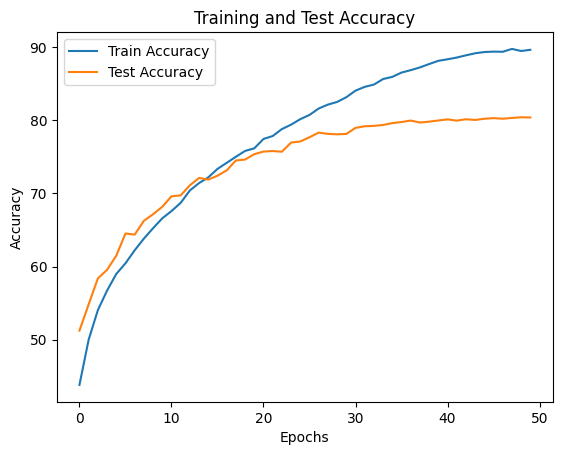

In [142]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Test Accuracy")
plt.show()